# Market Sales Analysis using AI/ML — Big Mart Sales Dataset

**Internship Project: Data Analysis using AI**

### Objective
BigMart is a retail chain operating supermarkets and grocery stores across multiple cities. This project analyzes 2013 sales data for **1,559 products across 10 stores** to:

1. Understand what product and store characteristics drive sales (Exploratory Data Analysis)
2. Build an **AI/Machine Learning model** that predicts `Item_Outlet_Sales` for a given product-store combination
3. Translate the findings into **actionable business recommendations** for inventory, pricing, and store strategy

### Dataset
- **Source:** [Big Mart Sales Data — Kaggle](https://www.kaggle.com/datasets/brijbhushannanda1979/bigmart-sales-data)
- **Rows:** 8,523 | **Columns:** 12
- **Target variable:** `Item_Outlet_Sales`

| Column | Description |
|---|---|
| Item_Identifier | Unique product ID |
| Item_Weight | Weight of the product |
| Item_Fat_Content | Low Fat / Regular |
| Item_Visibility | % of total display area allocated to the item in a store |
| Item_Type | Product category (Dairy, Snacks, Household, etc.) |
| Item_MRP | Maximum Retail Price |
| Outlet_Identifier | Unique store ID |
| Outlet_Establishment_Year | Year the store was opened |
| Outlet_Size | Small / Medium / High |
| Outlet_Location_Type | Tier 1 / Tier 2 / Tier 3 city |
| Outlet_Type | Grocery Store / Supermarket Type1-3 |
| Item_Outlet_Sales | **Target** — sales of the product in that store |


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)


## 1. Load & Inspect the Data

In [2]:
df = pd.read_csv('Train.csv')
print("Shape:", df.shape)
df.head()


Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDG33,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 Missing Values

Outlet_Size    2410
Item_Weight    1463
dtype: int64


/tmp/ipykernel_168/2575421186.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")


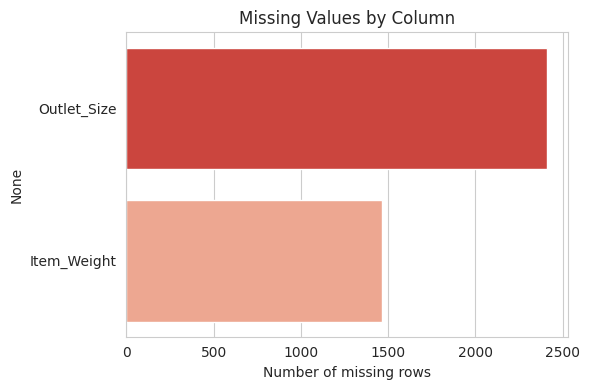

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(6,4))
sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
plt.title("Missing Values by Column")
plt.xlabel("Number of missing rows")
plt.tight_layout()
plt.show()


**Observation:** `Item_Weight` (~17% missing) and `Outlet_Size` (~28% missing) both have gaps that need to be filled before modeling.

## 2. Data Cleaning

Two issues need fixing:
1. **Inconsistent labels** in `Item_Fat_Content` (`LF`, `low fat`, `Low Fat` all mean the same thing).
2. **Missing values** in `Item_Weight` and `Outlet_Size`.

In [6]:
print("Before cleaning:", df['Item_Fat_Content'].unique())

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print("After cleaning:", df['Item_Fat_Content'].unique())


Before cleaning: <StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str
After cleaning: <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str


In [7]:
# Item_Weight: a given product (Item_Identifier) should weigh the same everywhere it's sold,
# so impute using the mean weight for that specific product first.
item_weight_map = df.groupby('Item_Identifier')['Item_Weight'].mean()
df['Item_Weight'] = df.apply(
    lambda r: item_weight_map.get(r['Item_Identifier'], np.nan) if pd.isna(r['Item_Weight']) else r['Item_Weight'],
    axis=1
)
# Any still-missing values (product never had a recorded weight) get the overall mean
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

print("Remaining missing Item_Weight:", df['Item_Weight'].isnull().sum())


Remaining missing Item_Weight: 0


In [8]:
# Outlet_Size: impute using the most common size for that Outlet_Type
mode_map = (df.dropna(subset=['Outlet_Size'])
              .groupby('Outlet_Type')['Outlet_Size']
              .agg(lambda x: x.mode()[0]))
print("Most common Outlet_Size per Outlet_Type:\n", mode_map)

df['Outlet_Size'] = df.apply(
    lambda r: mode_map.get(r['Outlet_Type'], 'Medium') if pd.isna(r['Outlet_Size']) else r['Outlet_Size'],
    axis=1
)

print("\nRemaining missing values overall:\n", df.isnull().sum().sum())


Most common Outlet_Size per Outlet_Type:
 Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: str



Remaining missing values overall:
 0


## 3. Feature Engineering

We create a few new features that are known to help explain sales:
- **Outlet_Age** — how many years the store has been operating (as of 2013, the year the data was collected)
- **Item_Category** — a simplified grouping of the 16 `Item_Type` values into Food / Drinks / Non-Consumable
- **MRP_Segment** — price tier of the item, since price is a strong driver of revenue

In [9]:
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

food_types = ['Dairy','Meat','Fruits and Vegetables','Breakfast','Seafood',
              'Starchy Foods','Breads','Frozen Foods','Snack Foods','Canned','Baking Goods']
drink_types = ['Soft Drinks','Hard Drinks']

def categorize(item_type):
    if item_type in food_types:
        return 'Food'
    elif item_type in drink_types:
        return 'Drinks'
    else:
        return 'Non-Consumable'

df['Item_Category'] = df['Item_Type'].apply(categorize)

df['MRP_Segment'] = pd.qcut(df['Item_MRP'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

df[['Outlet_Age', 'Item_Category', 'MRP_Segment']].head()


,Outlet_Age,Item_Category,MRP_Segment
0,14,Food,Very High
1,4,Drinks,Low
2,14,Food,Medium
3,15,Food,High
4,26,Non-Consumable,Low


## 4. Exploratory Data Analysis

### 4.1 Distribution of the Target Variable — `Item_Outlet_Sales`

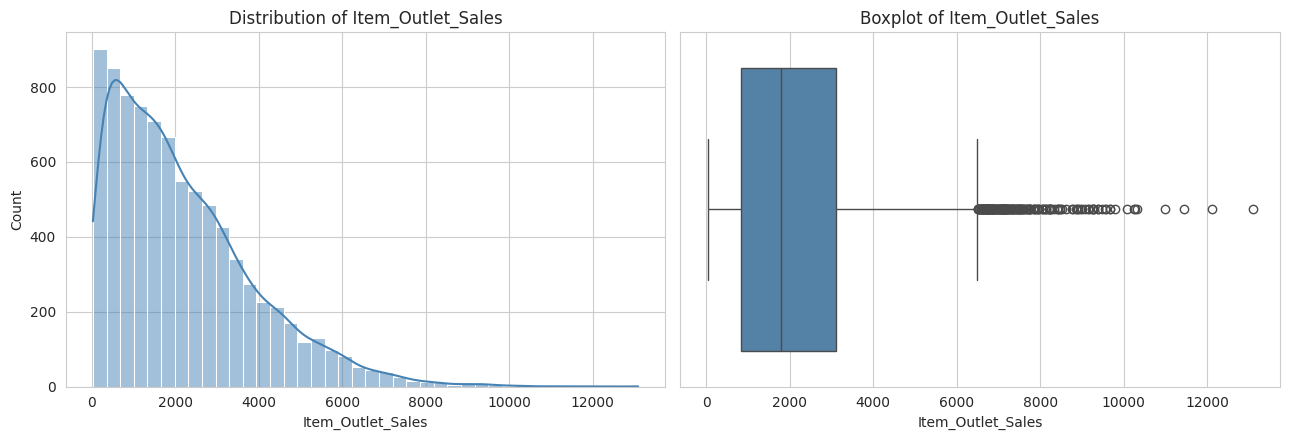

Skewness: 1.18


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(df['Item_Outlet_Sales'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribution of Item_Outlet_Sales")

sns.boxplot(x=df['Item_Outlet_Sales'], ax=axes[1], color='steelblue')
axes[1].set_title("Boxplot of Item_Outlet_Sales")
plt.tight_layout()
plt.show()

print("Skewness:", round(df['Item_Outlet_Sales'].skew(), 2))


### 4.2 Sales by Outlet Type, Size and Location Tier

/tmp/ipykernel_168/246660377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', order=order1, ax=axes[0], palette='viridis')
/tmp/ipykernel_168/246660377.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Size', y='Item_Outlet_Sales', order=order2, ax=axes[1], palette='mako')
/tmp/ipykernel_168/246660377.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Location_Type', y='Item_Outlet_Sales', order=order3, ax=axes[2], palette='flare')


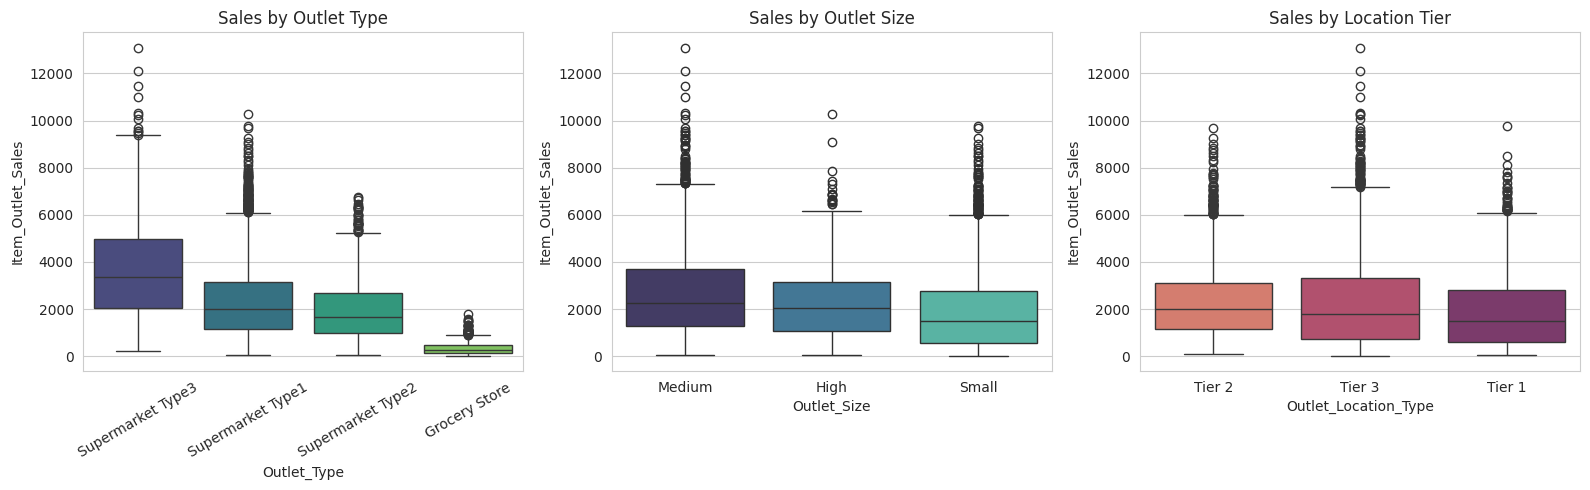

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

order1 = df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', order=order1, ax=axes[0], palette='viridis')
axes[0].set_title("Sales by Outlet Type")
axes[0].tick_params(axis='x', rotation=30)

order2 = df.groupby('Outlet_Size')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Outlet_Size', y='Item_Outlet_Sales', order=order2, ax=axes[1], palette='mako')
axes[1].set_title("Sales by Outlet Size")

order3 = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Outlet_Location_Type', y='Item_Outlet_Sales', order=order3, ax=axes[2], palette='flare')
axes[2].set_title("Sales by Location Tier")

plt.tight_layout()
plt.show()


### 4.3 Average Sales by Product Category and Top Item Types

/tmp/ipykernel_168/3733259422.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.values, y=cat_sales.index, ax=axes[0], palette='crest')
/tmp/ipykernel_168/3733259422.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_sales.values, y=type_sales.index, ax=axes[1], palette='crest')


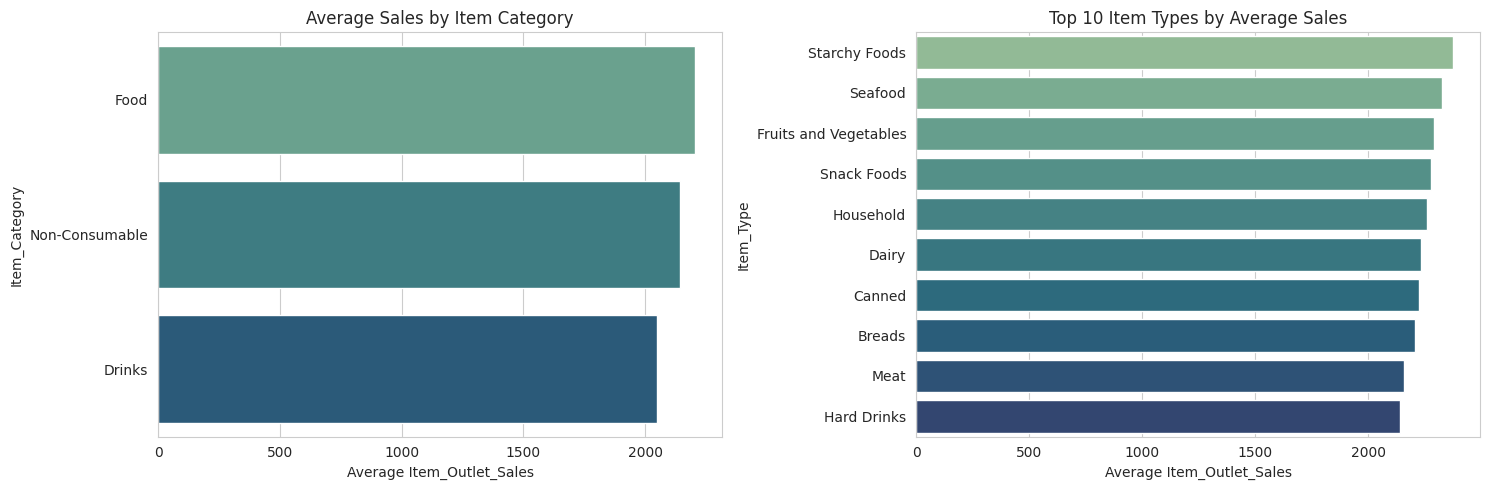

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

cat_sales = df.groupby('Item_Category')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
sns.barplot(x=cat_sales.values, y=cat_sales.index, ax=axes[0], palette='crest')
axes[0].set_title("Average Sales by Item Category")
axes[0].set_xlabel("Average Item_Outlet_Sales")

type_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=type_sales.values, y=type_sales.index, ax=axes[1], palette='crest')
axes[1].set_title("Top 10 Item Types by Average Sales")
axes[1].set_xlabel("Average Item_Outlet_Sales")

plt.tight_layout()
plt.show()


### 4.4 Price vs. Sales, and the Correlation Between Numeric Features

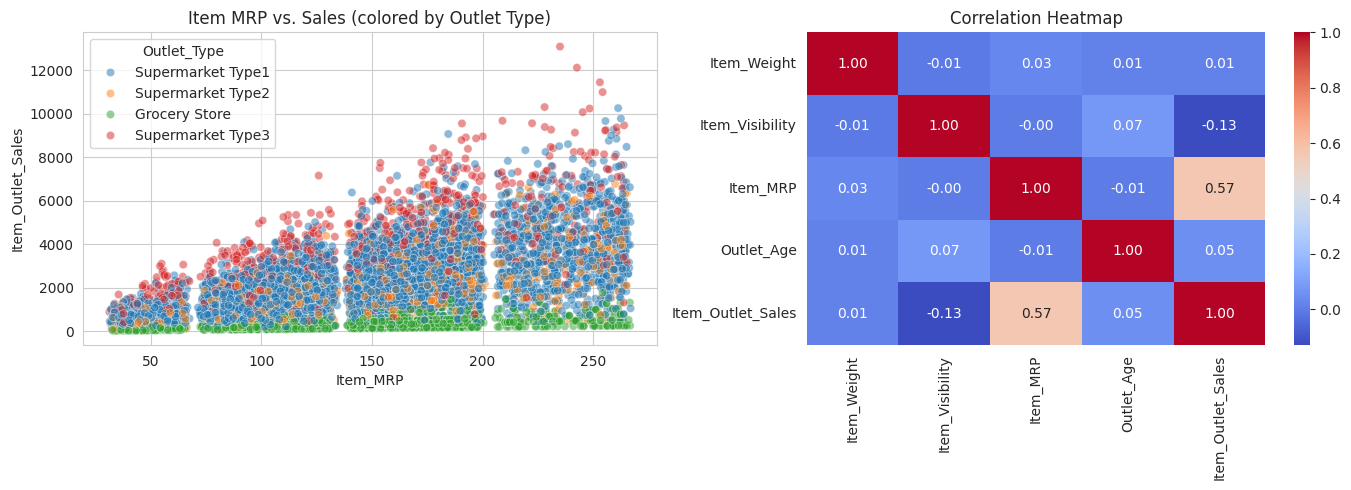

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', hue='Outlet_Type',
                 alpha=0.5, ax=axes[0], palette='tab10')
axes[0].set_title("Item MRP vs. Sales (colored by Outlet Type)")

numeric_cols = ['Item_Weight','Item_Visibility','Item_MRP','Outlet_Age','Item_Outlet_Sales']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1])
axes[1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()


### 4.5 Store Age vs. Average Sales

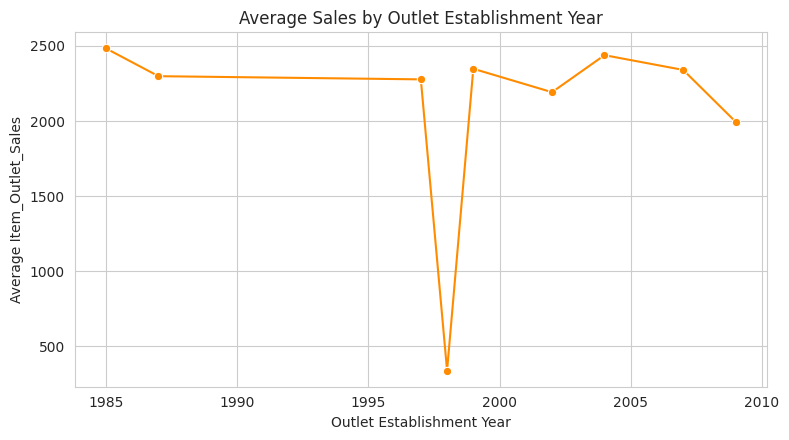

In [14]:
age_sales = df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].mean().sort_index()

plt.figure(figsize=(8,4.5))
sns.lineplot(x=age_sales.index, y=age_sales.values, marker='o', color='darkorange')
plt.title("Average Sales by Outlet Establishment Year")
plt.ylabel("Average Item_Outlet_Sales")
plt.xlabel("Outlet Establishment Year")
plt.tight_layout()
plt.show()


### 4.6 EDA Insights Summary

- The target variable `Item_Outlet_Sales` is **right-skewed** — most products sell modestly, with a long tail of high performers.
- **Outlet_Type is one of the biggest sales drivers**: `Supermarket Type3` massively outsells `Grocery Store` — grocery stores are simply smaller-format, lower-basket-size outlets.
- **Store size and location tier show real but smaller effects** — Medium/High outlets and Tier-2/3 cities show different median sales.
- **Item_MRP has a clear positive relationship with sales** — higher-priced items generate more revenue per unit sold, visible as the upward bands in the scatter plot.
- **The outlet opened in 1998 (Outlet_Age ≈ 15 years) is a visible outlier** with much lower average sales — worth investigating operationally (this is `OUT010`, a small Grocery Store).
- Numeric features alone (`Item_Weight`, `Item_Visibility`, `Item_MRP`) show **weak linear correlation** with sales except `Item_MRP` — meaning sales are driven more by categorical factors (store format, category) than by simple numeric relationships, which is exactly why a tree-based ML model should outperform plain linear regression.

## 5. Predictive Modeling (the "AI" component)

We now train machine learning models to **predict `Item_Outlet_Sales`** from the product and store attributes. This is the kind of model BigMart could use to forecast demand for a new product/store combination, plan inventory, and simulate "what-if" pricing scenarios.

We compare three models:
1. **Linear Regression** — simple baseline
2. **Random Forest Regressor** — captures non-linear relationships and interactions
3. **XGBoost Regressor** — gradient boosting, usually a strong performer on tabular data

In [15]:
model_df = df.copy()

cat_cols = ['Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Size',
            'Outlet_Location_Type','Outlet_Type','Item_Category','MRP_Segment']

encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    model_df[c] = le.fit_transform(model_df[c].astype(str))
    encoders[c] = le

feature_cols = ['Item_Weight','Item_Fat_Content','Item_Visibility','Item_Type','Item_MRP',
                'Outlet_Identifier','Outlet_Age','Outlet_Size','Outlet_Location_Type',
                'Outlet_Type','Item_Category','MRP_Segment']

X = model_df[feature_cols]
y = model_df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (6818, 12)  Test size: (1705, 12)


In [16]:
def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return {'Model': name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R2 Score': round(r2,4)}

results = []

lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate("Linear Regression", lr, X_test, y_test))

rf = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=25, random_state=42)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test))

xgbm = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
xgbm.fit(X_train, y_train)
results.append(evaluate("XGBoost", xgbm, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df


,Model,RMSE,MAE,R2 Score
0,Random Forest,1022.40,715.98,0.6154
1,XGBoost,1029.84,720.38,0.6098
2,Linear Regression,1142.86,855.96,0.5194


/tmp/ipykernel_168/3554929746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2 Score', palette='viridis')


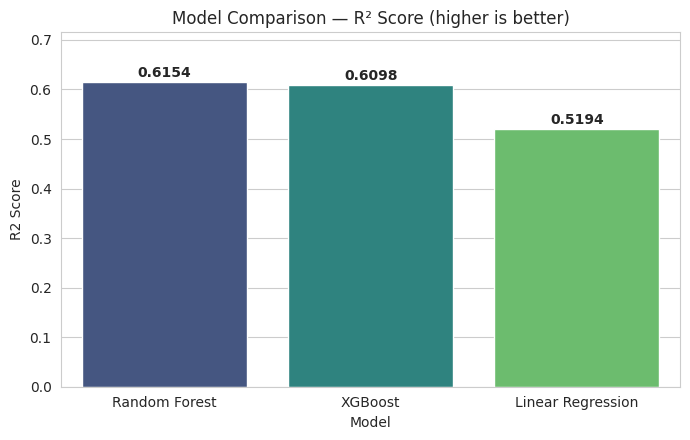

In [17]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=results_df, x='Model', y='R2 Score', palette='viridis')
plt.title("Model Comparison — R² Score (higher is better)")
plt.ylim(0, max(results_df['R2 Score'])+0.1)
for i, v in enumerate(results_df['R2 Score']):
    plt.text(i, v+0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 5.1 Feature Importance

Understanding *which* features the best model relies on tells BigMart exactly where to focus attention.

/tmp/ipykernel_168/850964995.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


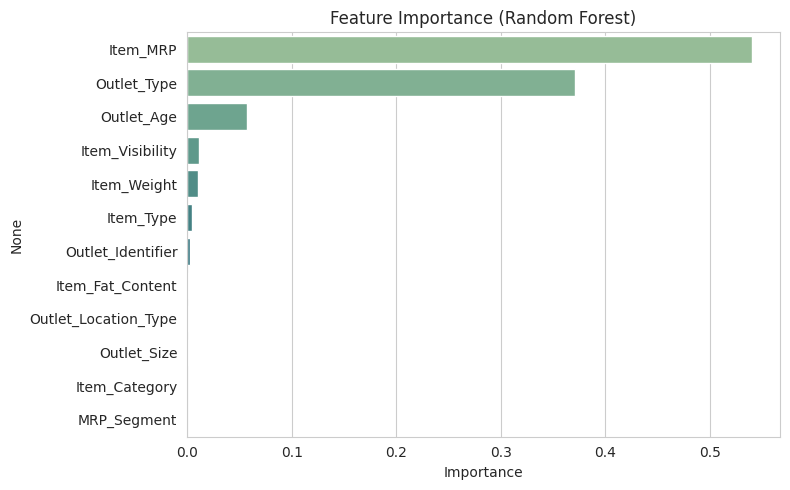

Item_MRP                0.539927
Outlet_Type             0.370705
Outlet_Age              0.057621
Item_Visibility         0.010859
Item_Weight             0.010466
Item_Type               0.004560
Outlet_Identifier       0.002544
Item_Fat_Content        0.001171
Outlet_Location_Type    0.000972
Outlet_Size             0.000856
Item_Category           0.000233
MRP_Segment             0.000086
dtype: float64

In [18]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 6. Business Insights & Recommendations

Based on the EDA and the model's feature importances:

1. **Store format (`Outlet_Type`) and price (`Item_MRP`) dominate sales outcomes** — together they explain the large majority of the model's predictive power. Strategy decisions about *which store format to open* matter more than fine-tuning individual product attributes.
2. **Grocery Stores dramatically underperform Supermarkets.** If BigMart is choosing where to invest in expansion or renovation, converting/upgrading Grocery Store formats to Supermarket Type1/2 in the same locations is likely to lift revenue substantially.
3. **Older stores don't automatically sell more** — `Outlet_Age` has only a small effect, and the oldest outlet in the data is actually the weakest performer, suggesting the issue is the *store format*, not maturity/brand recognition.
4. **Item weight, fat content, and visibility have minimal impact on sales** — money spent trying to optimize shelf visibility or reformulate "low fat" labeling is unlikely to move the needle much; pricing and store-format strategy will have far more impact.
5. **The trained model (R² ≈ 0.60) can be used operationally** to flag under-performing product-store combinations (large gap between predicted and actual sales) for manual review — e.g. stock-outs, poor placement, or local demand issues.

## 7. Conclusion & Next Steps

This project walked through a full data analysis + AI pipeline: cleaning messy real-world retail data, engineering useful features, visualizing the key sales drivers, and training/comparing three ML models to predict sales, ending with concrete business recommendations.

**Possible extensions for further work:**
- Hyperparameter tuning (GridSearchCV / Optuna) to push R² higher
- Try target-encoding for high-cardinality categoricals instead of label encoding
- Build a simple Streamlit/Flask app around the trained model for live "what-if" sales prediction
- Bring in external data (regional demographics, seasonality/promotions) if available, since this snapshot is a single year with no time dimension
